In [1]:
import pandas as pd

In [19]:
agg_res = pd.read_csv("aggregated_results.csv")
all_res = pd.read_csv("all_results.csv")

In [3]:
agg_res["perturbation"].unique()

<StringArray>
['subsampled', 'unbalanced', 'sparsified-tsid-varid']
Length: 3, dtype: str

In [4]:
agg_res["dataset"].unique()

<StringArray>
['mimic_iii', 'physionet_2012']
Length: 2, dtype: str

In [5]:
test_metrics = ['test_accuracy@0.5', 'test_auprc', 'test_auroc', 'test_balanced_accuracy@0.5', 'test_f1@0.5',
                'test_f2@0.5', 'test_minrp', 'test_precision@0.5', 'test_recall@0.5']

In [6]:
# Define fixed order and colors
model_order = ["gru", "tcn", "sand", "grud", "strats"]
colors = [
    "#8172B2",  # purple GRU
    "#4C72B0",  # blue   TCN
    "#55A868",  # green  SAND
    "#DD8452",  # orange GRUD
    "#C44E52",  # red    STRATS
]

### SUBSAMPLED

In [22]:
perturbation = 'subsampled'
dataset = 'physionet_2012'

In [23]:
sub_agg = agg_res[(agg_res["dataset"]==dataset)&(agg_res["perturbation"]==perturbation)]
#sub_agg.groupby(["model","perturbation","pct"]).size()

In [24]:
mean_sub_agg = sub_agg.groupby(["model","perturbation","pct"])[test_metrics].median().reset_index()

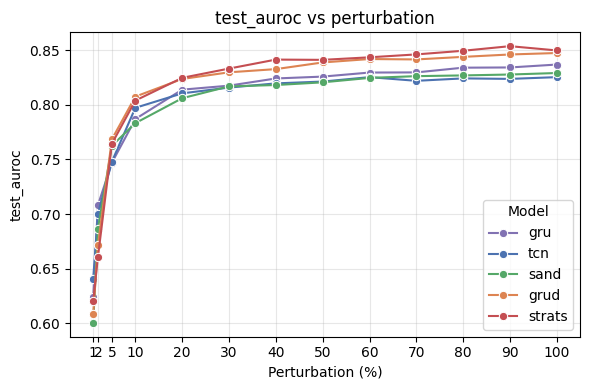

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

metric = "test_auroc"

plt.figure(figsize=(6,4))

sns.lineplot(
    data=mean_sub_agg,
    x="pct",
    y=metric,
    hue="model",
    hue_order=model_order,
    marker="o",
    dashes=False,
    palette=colors
)

plt.xlabel("Perturbation (%)")
plt.ylabel(metric)
plt.title(f"{metric} vs perturbation")
plt.xticks([1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
plt.grid(alpha=0.3)

plt.legend(title="Model")
plt.tight_layout()
plt.show()

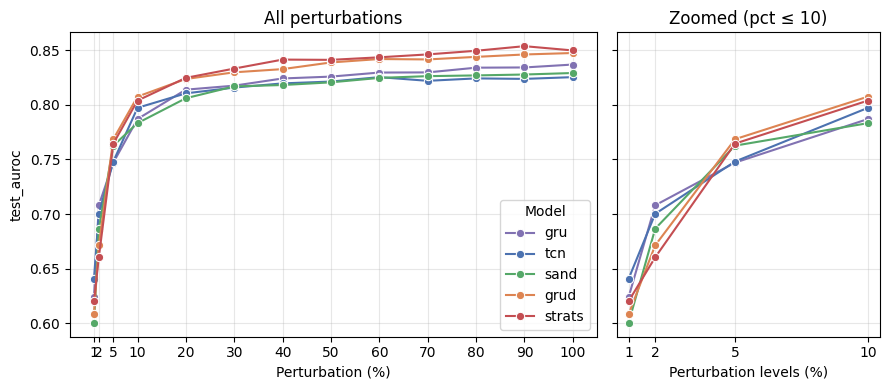

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

metric = "test_auroc"

# Create subplots with width ratio 2:1
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True, gridspec_kw={'width_ratios': [2, 1]})

# --- Full plot ---
sns.lineplot(
    data=mean_sub_agg,
    x="pct",
    y=metric,
    hue="model",
    hue_order=model_order,
    palette=colors,
    marker="o",
    dashes=False,
    ax=axes[0]
)
axes[0].set_xlabel("Perturbation (%)")
axes[0].set_ylabel(metric)
axes[0].set_title(f"All perturbations")
axes[0].set_xticks([1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
axes[0].grid(alpha=0.3)

# --- Zoomed plot (pct <= 10) ---
sns.lineplot(
    data=mean_sub_agg[mean_sub_agg["pct"] <= 10],
    x="pct",
    y=metric,
    hue="model",
    hue_order=model_order,
    palette=colors,
    marker="o",
    dashes=False,
    ax=axes[1],
    legend=False  # remove legend
)
axes[1].set_xlabel("Perturbation levels (%)")
axes[1].set_title(f"Zoomed (pct ≤ 10)")
axes[1].set_xticks([1, 2, 5, 10])
axes[1].grid(alpha=0.3)

# --- Legend only for the first plot ---
axes[0].legend(title="Model")

plt.tight_layout()
#plt.savefig(f"figures/{dataset}_{perturbation}1.png", dpi=300)
plt.show()

### SPARSIFIED

In [82]:
perturbation = 'sparsified-tsid-varid'
#dataset = 'physionet_2012'
dataset = 'mimic_iii'

sub_agg = agg_res[(agg_res["dataset"]==dataset)&(agg_res["perturbation"]==perturbation)]
sub_agg["pct"] = sub_agg["pct"].astype("int")
#sub_agg.groupby(["model","perturbation","pct"]).size()

mean_sub_agg = sub_agg.groupby(["model","perturbation","pct"])[test_metrics].median().reset_index()

<Figure size 600x400 with 0 Axes>

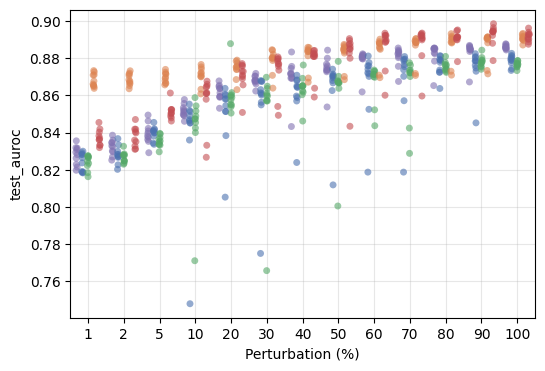

In [83]:
plt.figure(figsize=(6,4))

metric = "test_auroc"

plt.figure(figsize=(6,4))

# overlay scatter for all seeds
sns.stripplot(
    data=sub_agg,  # full dataframe with seeds
    x="pct",
    y=metric,
    hue="model",
    hue_order=model_order,
    palette=colors,
    dodge=True,   # separate points by model
    size=5,
    alpha=0.6,
    marker="o",
    jitter=True,  # small horizontal jitter to separate points
    legend=False,  # avoid double legend
    #native_scale=True
)

plt.xlabel("Perturbation (%)")
plt.ylabel(metric)
plt.grid(alpha=0.3)
plt.show()

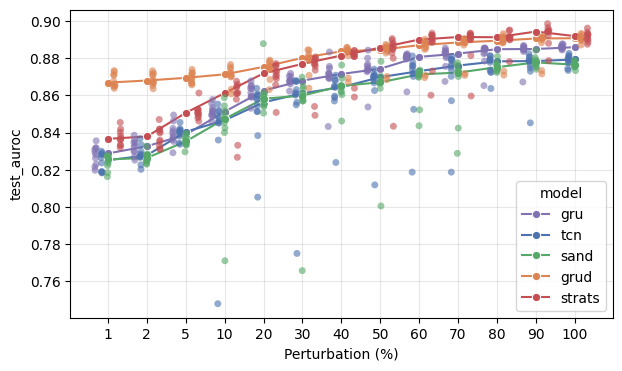

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
metric = "test_auroc"

# convert pct to strings for categorical stripplot
sub_agg = sub_agg.sort_values(by="pct")
sub_agg["pct_str"] = sub_agg["pct"].astype(str)
mean_sub_agg["pct_str"] = mean_sub_agg["pct"].astype(str)
pct_order = ["1","2","5","10","20","30","40","50","60","70","80","90","100"]

# plot stripplot first
ax = sns.stripplot(
    data=sub_agg,
    x="pct_str",
    y=metric,
    hue="model",
    hue_order=model_order,
    palette=colors,
    dodge=True,
    size=5,
    alpha=0.6,
    marker="o",
    jitter=True,
    legend=False
)

# now get the x-axis positions of the categories
x_positions = [tick.get_position()[0] for tick in ax.get_xticklabels()]

# plot lineplot using the same positions
pos_map = {cat: pos for cat, pos in zip(pct_order, x_positions)}
mean_sub_agg["x_pos"] = mean_sub_agg["pct_str"].map(pos_map)

sns.lineplot(
    data=mean_sub_agg,
    x="x_pos",
    y=metric,
    hue="model",
    hue_order=model_order,
    marker="o",
    dashes=False,
    palette=colors,
    ax=ax
)

# fix x ticks
ax.set_xticks(x_positions)
ax.set_xticklabels(pct_order)
ax.legend(loc="lower right", title="model")
plt.xlabel("Perturbation (%)")
plt.ylabel(metric)
plt.grid(alpha=0.3)
#plt.savefig(f"figures/{dataset}_{perturbation}1.png", dpi=300)
plt.show()

### IMBALANCED

In [100]:
perturbation = 'unbalanced'
dataset = 'physionet_2012'
#dataset = 'mimic_iii'

sub_agg = agg_res[(agg_res["dataset"]==dataset)&(agg_res["perturbation"]==perturbation)]
sub_agg["pct"] = sub_agg["pct"].astype("int")
#sub_agg.groupby(["model","perturbation","pct"]).size()

mean_sub_agg = sub_agg.groupby(["model","perturbation","pct"])[test_metrics].median().reset_index()

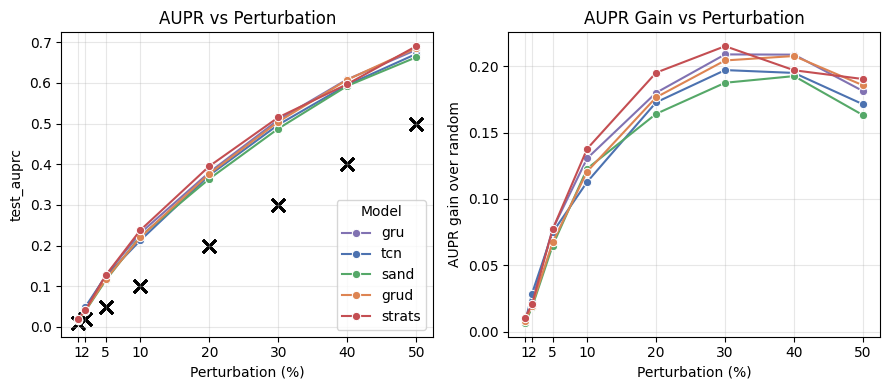

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

metric = "test_auprc"

# Compute random baseline per perturbation
mean_sub_agg['random_baseline'] = mean_sub_agg['pct'] / 100
mean_sub_agg['aupr_gain'] = mean_sub_agg[metric] - mean_sub_agg['random_baseline']

fig, axes = plt.subplots(1, 2, figsize=(9, 4), gridspec_kw={'width_ratios':[1,1]})

# --- First subplot: actual AUPR with random baseline ---
sns.lineplot(
    data=mean_sub_agg,
    x="pct",
    y=metric,
    hue="model",
    hue_order=model_order,
    marker="o",
    dashes=False,
    palette=colors,
    ax=axes[0]
)

# overlay crosses for random baseline
for pct, rnd in zip(mean_sub_agg['pct'], mean_sub_agg['random_baseline']):
    axes[0].scatter(
        [pct]*len(model_order),
        [rnd]*len(model_order),
        marker='x',
        color='black',
        s=80
    )

axes[0].set_xlabel("Perturbation (%)")
axes[0].set_ylabel(metric)
axes[0].set_xticks([1, 2, 5, 10, 20, 30, 40, 50])
axes[0].grid(alpha=0.3)
axes[0].set_title("AUPR vs Perturbation")

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(), title="Model", loc='lower right')

# --- Second subplot: AUPR gain over random ---
sns.lineplot(
    data=mean_sub_agg,
    x="pct",
    y="aupr_gain",
    hue="model",
    hue_order=model_order,
    marker="o",
    dashes=False,
    palette=colors,
    ax=axes[1]
)

#
axes[1].set_xlabel("Perturbation (%)")
axes[1].set_ylabel("AUPR gain over random")
axes[1].set_xticks([1, 2, 5, 10, 20, 30, 40, 50])
axes[1].grid(alpha=0.3)
axes[1].set_title("AUPR Gain vs Perturbation")
axes[1].legend_.remove()  # remove legend from second plot

plt.tight_layout()
plt.savefig(f"figures/{dataset}_{perturbation}1.png", dpi=300)
plt.show()

In [36]:
test_metrics

['test_accuracy@0.5',
 'test_auprc',
 'test_auroc',
 'test_balanced_accuracy@0.5',
 'test_f1@0.5',
 'test_f2@0.5',
 'test_minrp',
 'test_precision@0.5',
 'test_recall@0.5']

### COMPARISON w MIMIC NF

In [102]:
import pandas as pd
import os

saved_data_path = "/home/christel-sirocchi/GitHub/FLABNET/flabnet-pipeline/MIMIC_IV/saved_data"

all_dfs = []

for model in ["gru", "tcn", "sand","grud"]:
    for fold in range(5):
        try:
            paths = {
            "MIMIC IV Neutropenic Fever" : os.path.join(
                saved_data_path,
                f"results/mimic_cohort_NF_30_days/time_series/standard/{model}/SIMU/fold_{fold}/grid_best/results_final.csv"),

            "Physionet Multiperturbed" : os.path.join(
                saved_data_path,
                f"results/mimic_physionet_2012_multiperturbed_OM_{fold}/time_series/standard/{model}/SIMU/fold_0/grid_best_epochs/results_final.csv"),
            
            "Physionet Original" : os.path.join(
                saved_data_path,
                f"results/mimic_physionet_2012/time_series/standard/{model}/SIMU/fold_{fold}/grid_best_epochs/results_final.csv")
            }
            for type, path in paths.items():
                df = pd.read_csv(path)

                # Add extra info about model and fold
                df["model"] = model
                df["fold"] = fold
                df["type"] = type

                all_dfs.append(df)

        except FileNotFoundError:
            print(f"⚠️ File not found for model={model}, fold={fold}: {path}")
        except pd.errors.EmptyDataError:
            print(f"⚠️ CSV empty for model={model}, fold={fold}: {path}")
        except Exception as e:
            print(f"⚠️ Error reading file for model={model}, fold={fold}: {e}")

# Concatenate all DataFrames
if all_dfs:
    final_df = pd.concat(all_dfs, ignore_index=True)
    print(f"✅ Concatenated {len(all_dfs)} datasets into one DataFrame with shape {final_df.shape}")
else:
    final_df = pd.DataFrame()
    print("⚠️ No datasets to concatenate.")

⚠️ File not found for model=grud, fold=0: /home/christel-sirocchi/GitHub/FLABNET/flabnet-pipeline/MIMIC_IV/saved_data/results/mimic_physionet_2012/time_series/standard/grud/SIMU/fold_0/grid_best_epochs/results_final.csv
⚠️ File not found for model=grud, fold=1: /home/christel-sirocchi/GitHub/FLABNET/flabnet-pipeline/MIMIC_IV/saved_data/results/mimic_physionet_2012_multiperturbed_OM_1/time_series/standard/grud/SIMU/fold_0/grid_best_epochs/results_final.csv
⚠️ File not found for model=grud, fold=2: /home/christel-sirocchi/GitHub/FLABNET/flabnet-pipeline/MIMIC_IV/saved_data/results/mimic_physionet_2012_multiperturbed_OM_2/time_series/standard/grud/SIMU/fold_0/grid_best_epochs/results_final.csv
⚠️ File not found for model=grud, fold=3: /home/christel-sirocchi/GitHub/FLABNET/flabnet-pipeline/MIMIC_IV/saved_data/results/mimic_physionet_2012_multiperturbed_OM_3/time_series/standard/grud/SIMU/fold_0/grid_best_epochs/results_final.csv
⚠️ File not found for model=grud, fold=4: /home/christel-sir

In [114]:
metrics = ['auroc', 'auprc', 'minrp', 'precision', 'recall', 'balanced_acc', 'mcc', 'f1','f2']
final_df = final_df[["type","model","fold"] + metrics]
final_df.head()

,type,model,fold,auroc,auprc,minrp,precision,recall,balanced_acc,mcc,f1,f2
0,MIMIC IV Neutropenic Fever,gru,0,0.799686,0.210537,0.223684,0.130293,0.754717,0.741963,0.233362,0.222222,0.385356
1,Physionet Multiperturbed,gru,0,0.794922,0.393550,0.434783,0.458167,0.337243,0.635564,0.309325,0.388514,0.356037
2,Physionet Original,gru,0,0.865805,0.539214,0.536232,0.387097,0.774194,0.785492,0.442047,0.516129,0.645161
3,MIMIC IV Neutropenic Fever,gru,1,0.790488,0.107881,0.157407,0.118367,0.659091,0.727369,0.214144,0.200692,0.344418
4,Physionet Multiperturbed,gru,1,0.769961,0.161874,0.214286,0.119048,0.555556,0.688146,0.190043,0.196078,0.320513


/tmp/ipykernel_372570/620495556.py:10: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.boxplot(
/tmp/ipykernel_372570/620495556.py:10: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.boxplot(
/tmp/ipykernel_372570/620495556.py:10: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.boxplot(


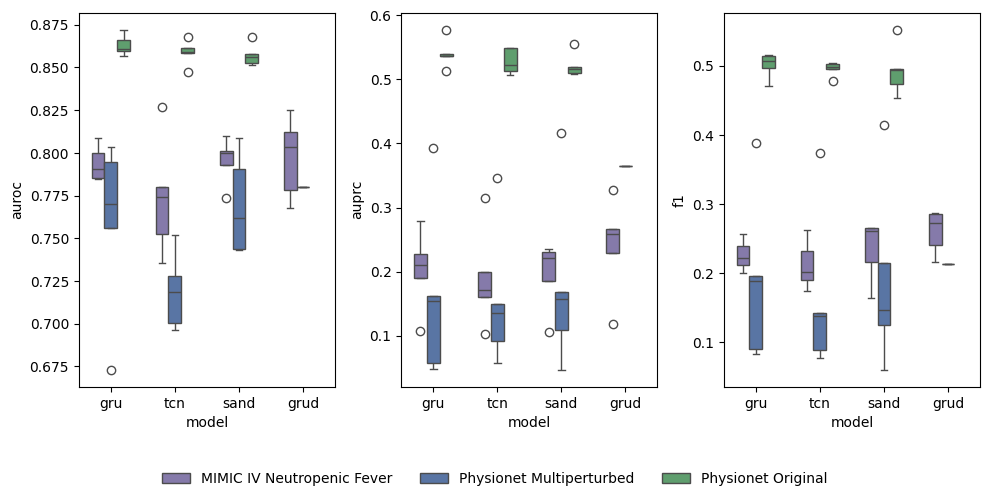

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["auroc", "auprc", "f1"]
fig, axes = plt.subplots(1, 3, figsize=(10,5), sharey=False)  # sharey=False in case scales differ

# loop through metrics and axes
for ax, metric in zip(axes, metrics):
    # boxplot
    sns.boxplot(
        data=final_df,
        x="model",
        y=metric,
        hue="type",
        palette=colors,
        width=0.6,
        ax=ax
    )
axes[0].get_legend().remove()
axes[1].get_legend().remove()
axes[2].get_legend().remove()
# handle legend outside the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="", loc='lower center', ncol=len(model_order), frameon=False)

plt.tight_layout(rect=[0,0.1,1,1])
plt.savefig("figures/nf_comparison.png", dpi=300)
plt.show()